In [104]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

%matplotlib inline

In [113]:
# Read data
df = pd.read_csv("../data/processed_data/Final_metabric_data_mice_imputed.tsv", sep='\t', index_col= 'Patient ID')
df = df.drop(columns=["Relapse Free Status", "Patient's Vital Status", "Relapse Free Status (Months)"])

--- TMB (nonsynonymous) Stats ---
IQR: 5.23 | Lower Outlier Threshold: -3.92 | Upper Outlier Threshold: 17.00

--- Age at Diagnosis Stats ---
IQR: 19.18 | Lower Outlier Threshold: 22.65 | Upper Outlier Threshold: 99.37

--- Cohort Stats ---
IQR: 2.00 | Lower Outlier Threshold: -2.00 | Upper Outlier Threshold: 6.00

--- Tumor Size Stats ---
IQR: 13.00 | Lower Outlier Threshold: -2.50 | Upper Outlier Threshold: 49.50

--- Nottingham prognostic index Stats ---
IQR: 2.00 | Lower Outlier Threshold: 0.05 | Upper Outlier Threshold: 8.03

--- homdel Stats ---
IQR: 0.04 | Lower Outlier Threshold: -0.06 | Upper Outlier Threshold: 0.10

--- hetloss Stats ---
IQR: 19.70 | Lower Outlier Threshold: -25.30 | Upper Outlier Threshold: 53.49

--- gain Stats ---
IQR: 8.84 | Lower Outlier Threshold: -10.10 | Upper Outlier Threshold: 25.26

--- amp Stats ---
IQR: 4.56 | Lower Outlier Threshold: -6.68 | Upper Outlier Threshold: 11.57

--- Overall Survival (Months) Stats ---
IQR: 124.27 | Lower Outlier Thres

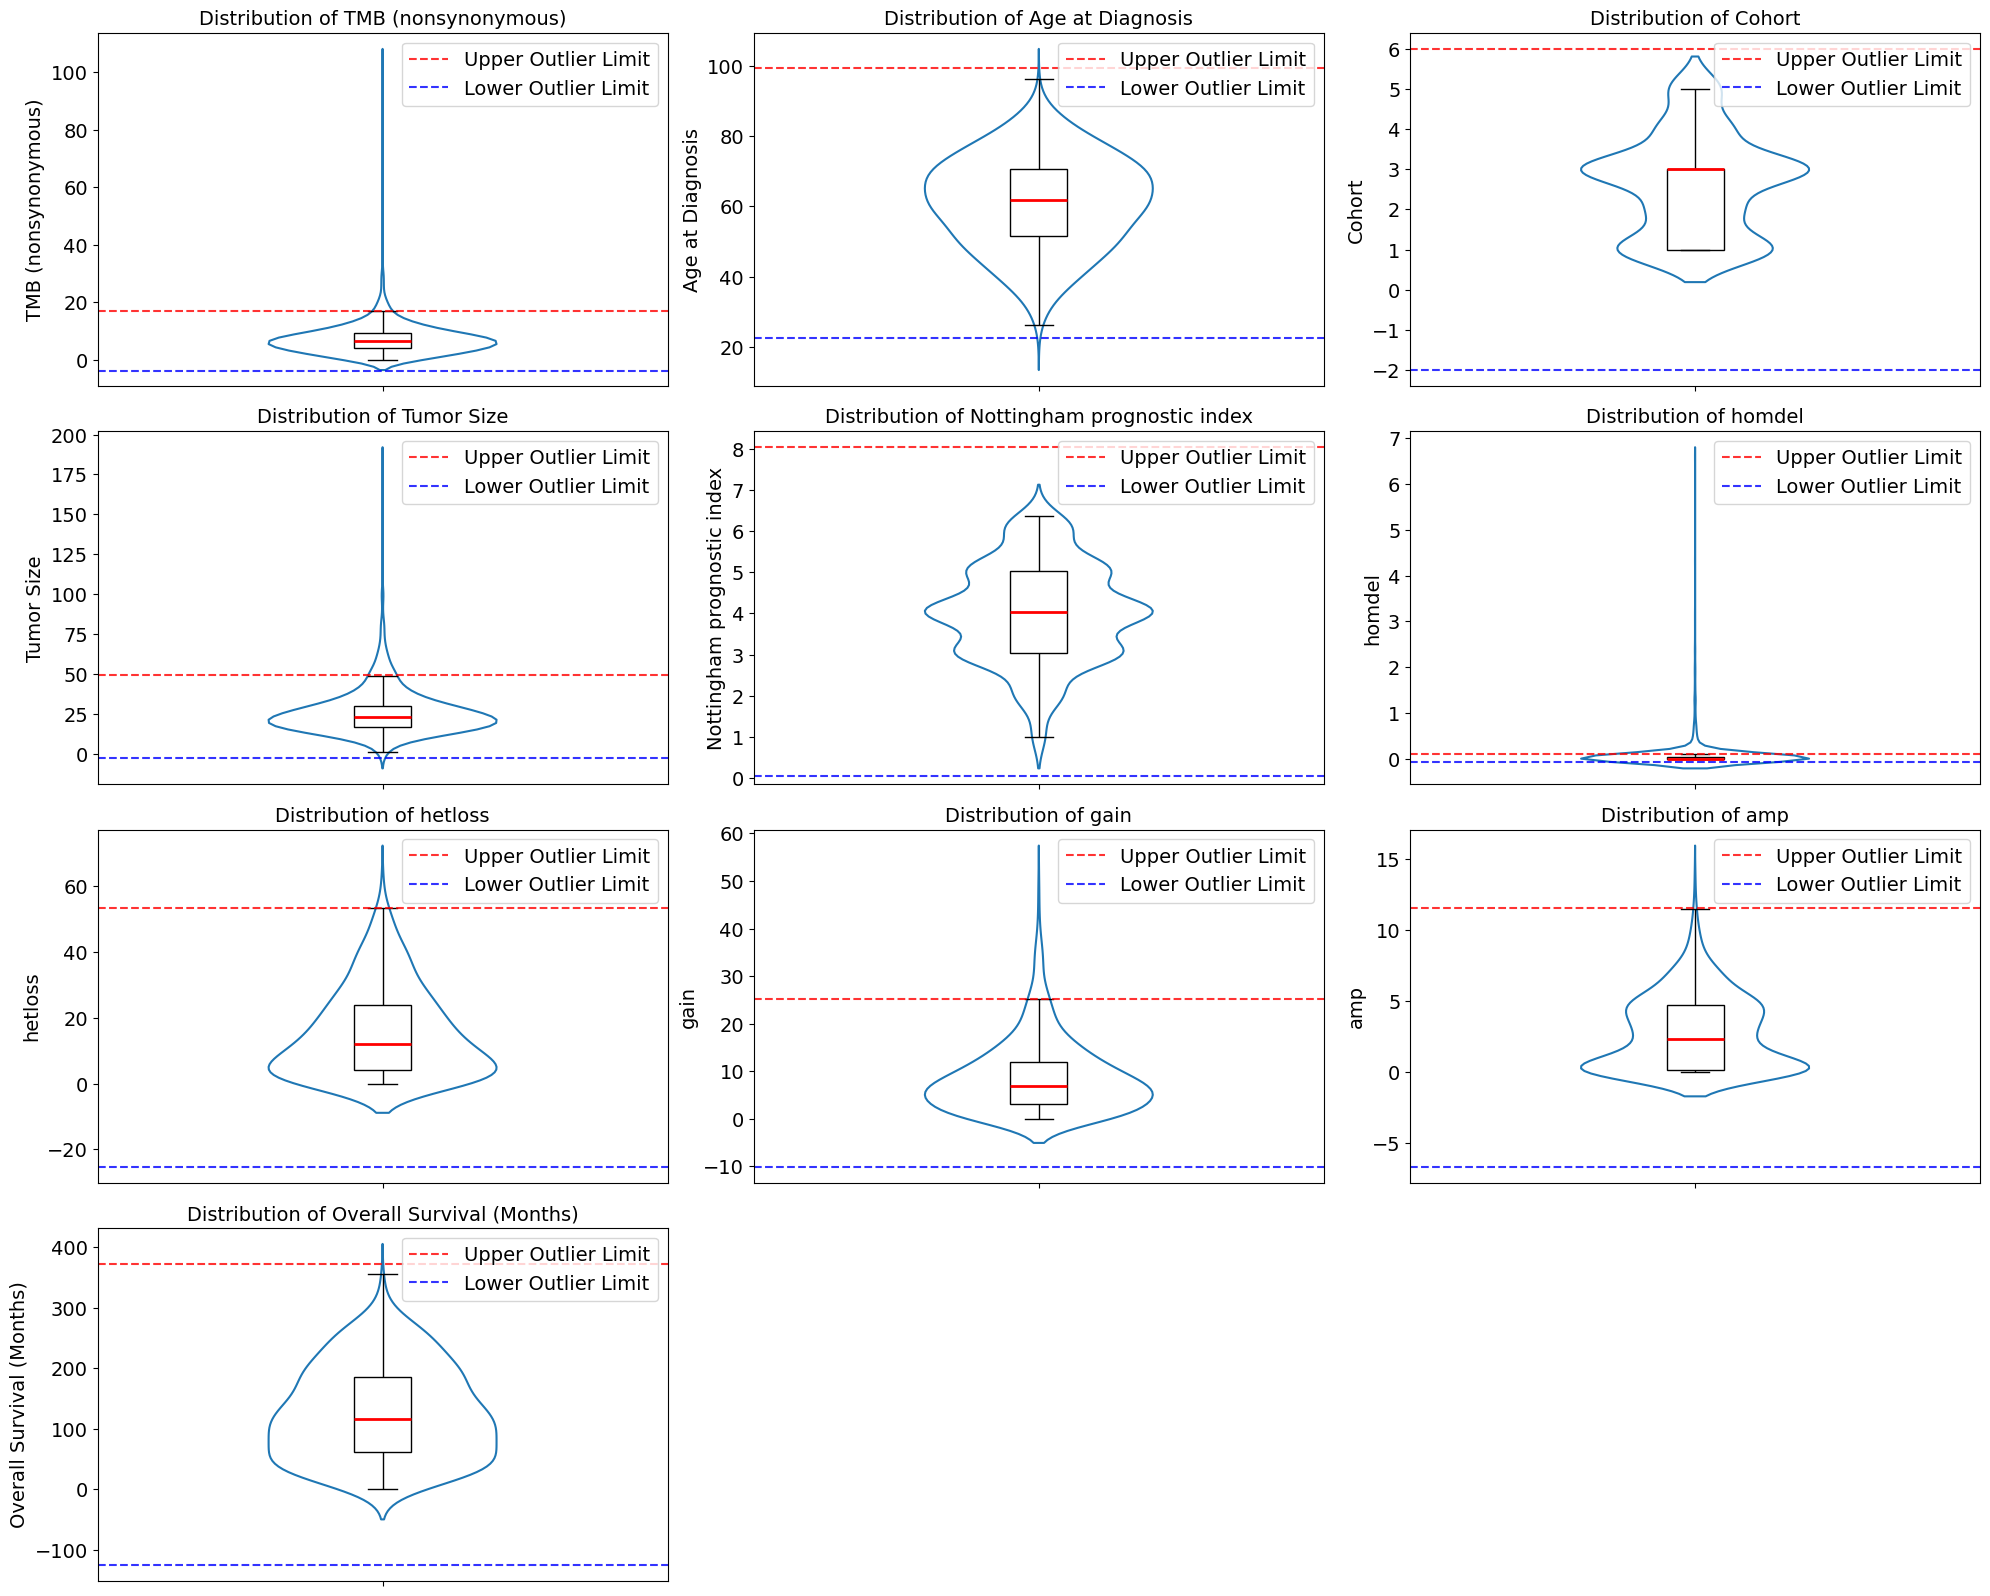

In [114]:
# Making violin plot to check for distribution and outliers in numerical features

num_features = df.select_dtypes(include=np.number).columns
plt.figure(figsize= (20, 20))
for i, col in enumerate(num_features,1):
    plt.subplot(5, 3, i)

    # Calculating IQR for outliers 
    clean_series = df[col].dropna()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    print(f"--- {col} Stats ---")
    print(f"IQR: {iqr:.2f} | Lower Outlier Threshold: {lower_bound:.2f} | Upper Outlier Threshold: {upper_bound:.2f}\n")
    
    
    ax = sns.violinplot(
    y=df[col], fill=False, width=0.4,
    inner=None,            # turn off inner marks; we'll draw them ourselves
    bw_adjust=1.5,)
    sns.boxplot(
        y=df[col], width=0.1, ax=ax, showfliers=False,
        boxprops=dict(facecolor='white', edgecolor='black'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markerfacecolor='black',
                    markeredgecolor='black', markersize=4))

    plt.axhline(upper_bound, color='red', linestyle='--', alpha=0.8, label='Upper Outlier Limit')
    plt.axhline(lower_bound, color='blue', linestyle='--', alpha=0.8, label='Lower Outlier Limit')
    plt.tick_params(which='both', labelsize=14)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.ylabel(f'{col}', fontsize=14)
    plt.legend(loc='upper right', fontsize='14')    

plt.tight_layout()
plt.savefig('../results/distribution_of_numerical_features.png', dpi=300, pil_kwargs={'compression':'png_lzw'})
plt.show()
 

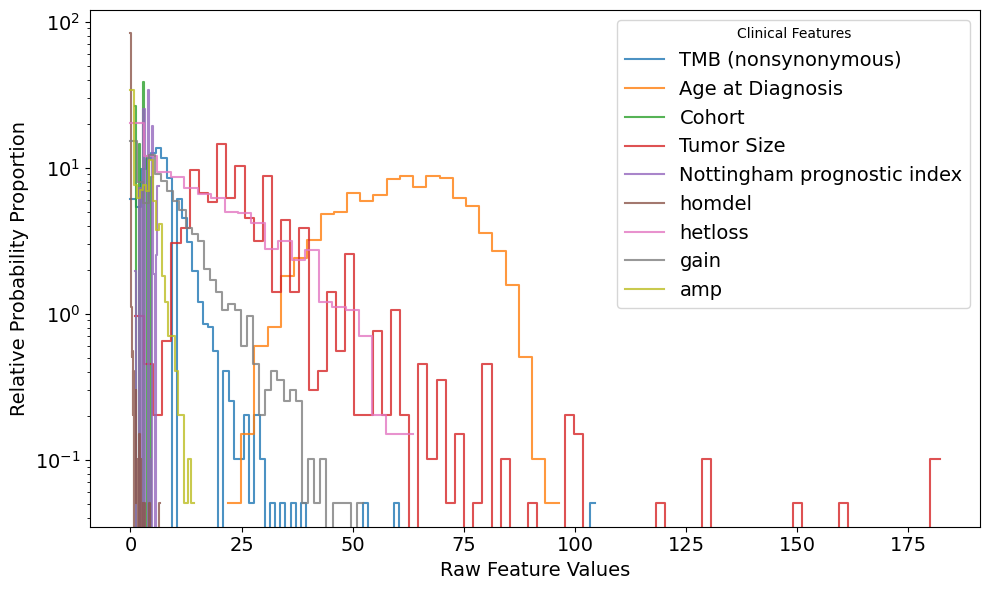

In [116]:
# 1. isolate your continuous numerical columns
df_copy = df.copy()
df_copy = df_copy.drop(columns=['Overall Survival (Months)'])

num_cols = df_copy.select_dtypes(include=np.number).columns 

plt.figure(figsize=(10, 6))

# 2. Plot each feature with its y-axis converted to a 0-1 probability scale
for col in num_cols:
    sns.histplot(
        df_copy[col], 
        element="step",      
        stat="percent",   # Forces the Y-axis to represent a 0 to 1 scale
        fill=False,
        common_norm=False,    # Scales each feature independently to its own total percentage
        alpha=0.8, 
        label=col
    )

# 3. Secure your Y-axis window from 0 to 1
#plt.ylim(0, 1)
plt.yscale('log')

# 4. Labeling and aesthetics
plt.xlabel("Raw Feature Values", fontsize=14)
plt.ylabel("Relative Probability Proportion", fontsize=14)
plt.legend(title="Clinical Features", loc="upper right", fontsize=14)
plt.tick_params(which='both', labelsize=14)
plt.tight_layout()
plt.show()

In [117]:
# 2. Build the summary table referencing the actual DataFrame data
range_summary = pd.DataFrame({
    'Min Value': df[num_cols].min(),
    'Max Value': df[num_cols].max(),
})

print(range_summary)

                             Min Value   Max Value
TMB (nonsynonymous)               0.00  104.601416
Age at Diagnosis                 21.93   96.290000
Cohort                            1.00    5.000000
Tumor Size                        1.00  182.000000
Nottingham prognostic index       1.00    6.360000
homdel                            0.00    6.595000
hetloss                           0.00   63.513000
gain                              0.00   52.362000
amp                               0.00   14.262000


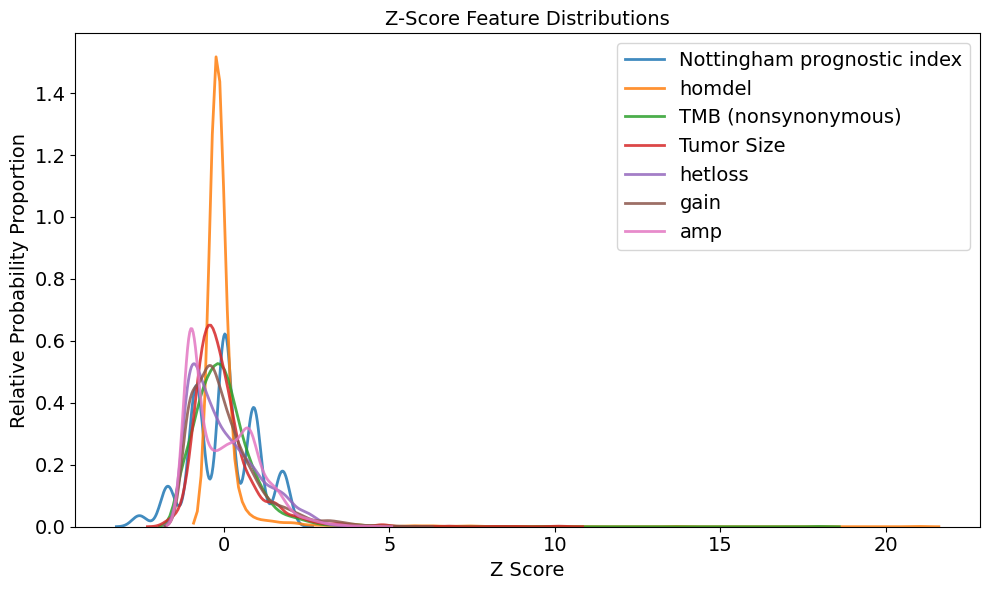

In [118]:
# 1. Isolate your continuous numerical columns
num_cols = ['Nottingham prognostic index', 'homdel', 'TMB (nonsynonymous)', 'Tumor Size', 'hetloss', 'gain','amp']

# 2. Create a safe copy of the dataframe to protect the raw data
df_scaled = df.copy()

plt.figure(figsize=(10, 6))

# 3. Loop through columns, compute Z-scores, save to df_scaled, and plot
for col in num_cols:
    # Perform manual Z-score transformation
    mean_val = df_scaled[col].mean()
    std_val = df_scaled[col].std()
    z_scaled_series = pd.Series(zscore(df_scaled[col], ddof=1), index=df_scaled.index)
    
    # Save the transformed values into the copied dataframe
    df_scaled[col] = z_scaled_series
    
    # Plot the Z-scaled distribution from the new dataframe
    sns.kdeplot(
        df_scaled[col], fill=False, label=col, alpha=0.85, linewidth=2
    )

# 4. Labeling updates to reflect the new standard scale
plt.title("Z-Score Feature Distributions", fontsize=14)
plt.xlabel("Z Score", fontsize=14)
plt.ylabel("Relative Probability Proportion", fontsize=14)
plt.legend(loc="upper right", fontsize=14)
plt.tick_params(which='both', labelsize=14)
plt.tight_layout()
plt.show()

df_scaled.to_csv("../data/processed_data/Final_metabric_data_scaled.tsv", sep ='\t')

In [119]:
# 5. Verification check to see the newly scaled dataframe head
df_scaled[num_cols].head()

,Nottingham prognostic index,homdel,TMB (nonsynonymous),Tumor Size,hetloss,gain,amp
Patient ID,,,,,,,
MB-0000,1.749301,-0.258395,-1.285418,-0.280601,-1.138400,-1.104074,-1.055570
MB-0002,0.007783,2.188808,-0.804782,-1.065385,0.753774,-0.545720,-0.626335
MB-0005,0.016387,-0.171569,-0.804782,-0.738392,-1.136036,2.239854,0.893823
MB-0006,0.033596,-0.126548,-1.045100,-0.084406,-0.620754,1.184468,-0.442213
MB-0008,1.780277,-0.097606,-0.804782,0.896574,-0.296219,-0.643319,-0.315629


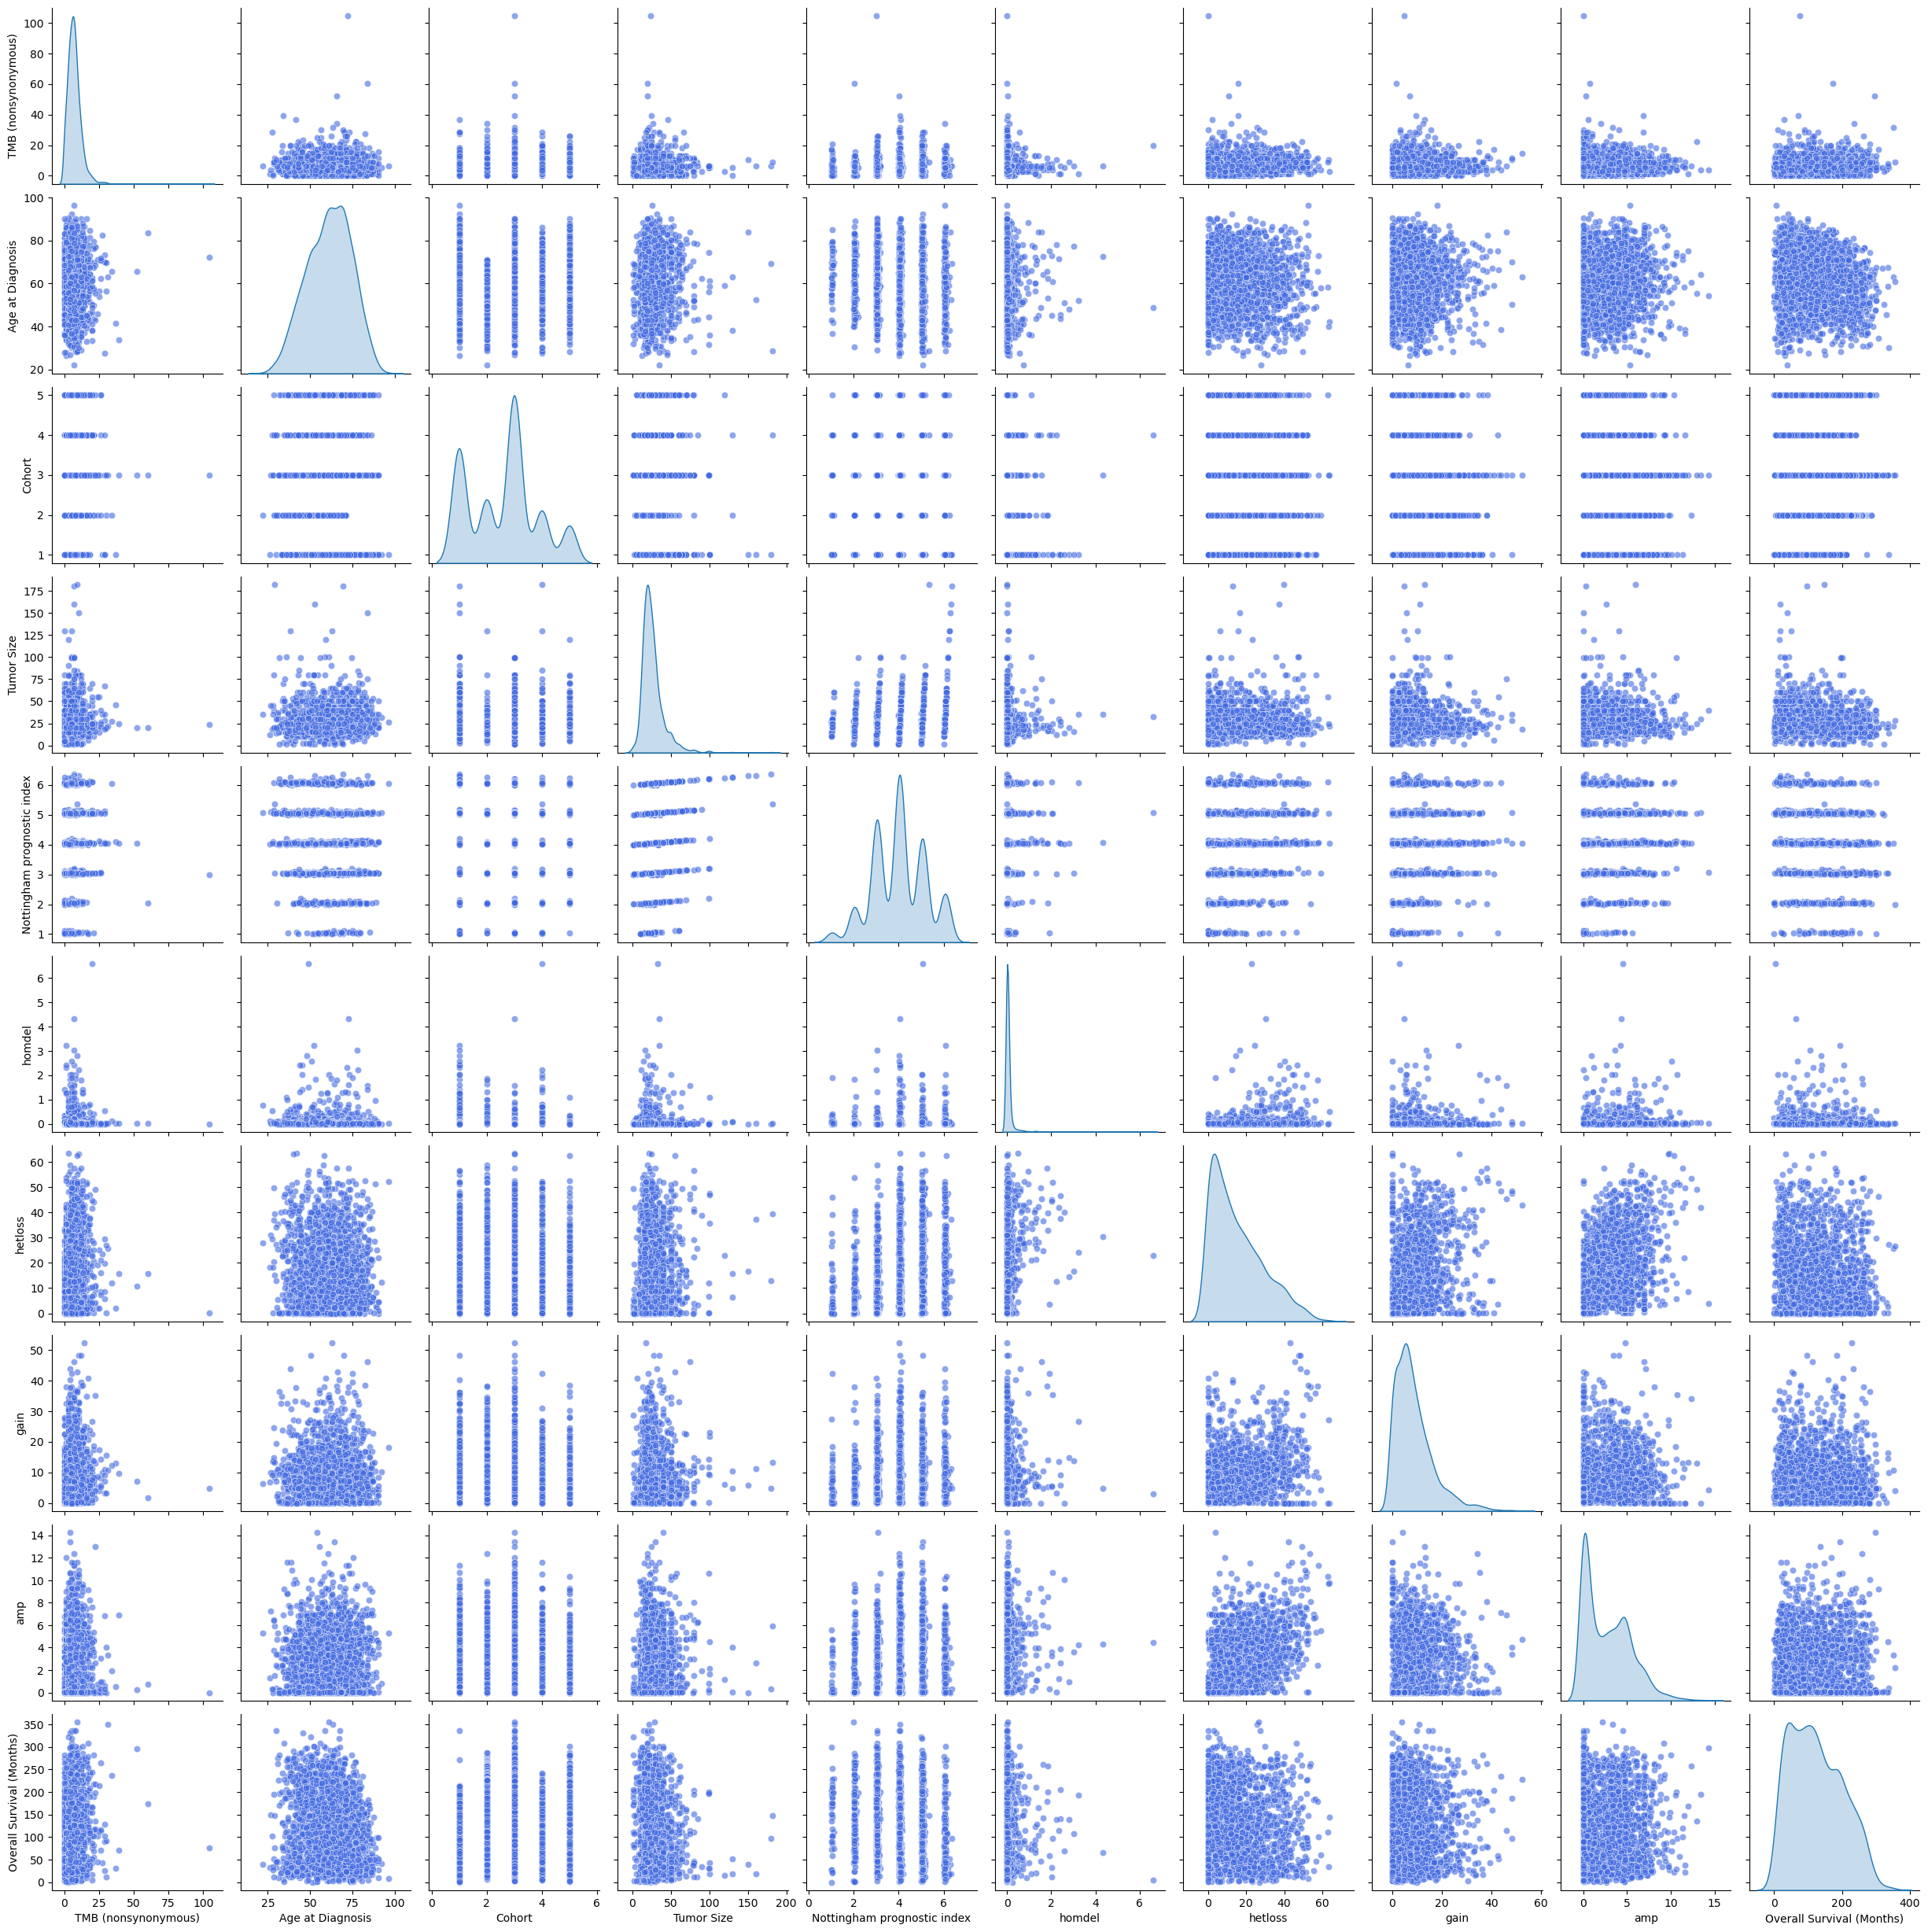

In [120]:
df_clean = df.copy()
num_features = df_clean.select_dtypes(include=np.number).columns.tolist()

g = sns.pairplot(
    df_clean,
    vars=num_features,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'color': 'royalblue'},
    height=2.5,
)

# Apply tick label size across every subplot
for ax in g.axes.flatten():
    ax.tick_params(labelsize=10)

g.savefig(
    "../results/numerical_features_pairplot.png",
    dpi=300,
    pil_kwargs={'compress_level': 9},
)

In [122]:
# 1. Split df_clean into X (features)
X_raw = df_clean.drop(columns=['Overall Survival Status', 'Overall Survival (Months)'])

# 2. Identify column types based purely on the features
categorical_cols = X_raw.select_dtypes(include=np.object_).columns.tolist()
numerical_cols = X_raw.select_dtypes(include=np.number).columns.tolist()

# Setup the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_cols,
        )
    ],
    remainder='passthrough',
)

# 3. Transform only the features
X_train_encoded_arr = preprocessor.fit_transform(X_raw)

# Extract encoded names and rebuild DataFrame cleanly
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = encoded_cat_names + numerical_cols
X_train_encoded = pd.DataFrame(
    X_train_encoded_arr, columns=all_feature_names)


In [126]:
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numerical_cols),
    ],
    remainder='drop',   # everything is now explicitly handled
)

X_train_encoded_arr = preprocessor.fit_transform(X_raw)

encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = encoded_cat_names + numerical_cols
X_train_encoded = pd.DataFrame(X_train_encoded_arr, columns=all_feature_names, index=X_raw.index)

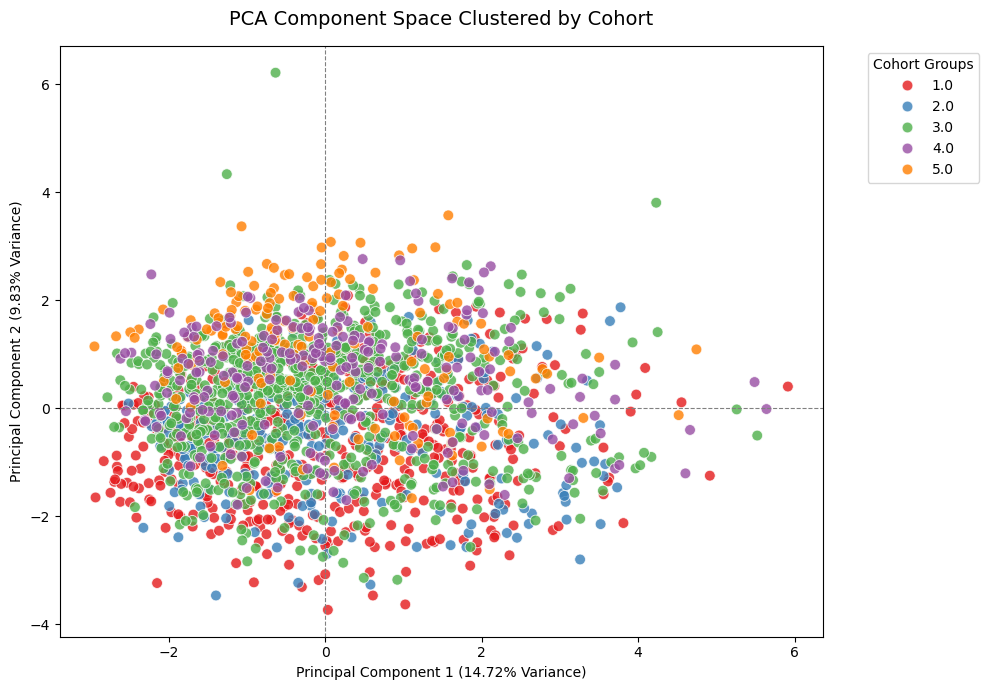

In [128]:
# 1. Extract your cohort/group column from your clean metadata
# (Make sure 'Cohort' matches the exact column name in your original df_clean)
cohort_labels = df_clean['Cohort'].values  

# 2. Initialize and fit PCA (Reducing to the first 2 principal components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_encoded)

# 3. Calculate the percentage of variance explained by each component
explained_variance = pca.explained_variance_ratio_ * 100

# 4. Build a temporary DataFrame for clean plotting with Seaborn
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cohort': cohort_labels
})

# 5. Plot the PCA Scatter
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Cohort', 
    palette='Set1',      # Clean, distinct color palette
    alpha=0.8, 
    edgecolor='w', 
    s=60                 # Size of the data points
)

# 6. Add dynamic axis labels showing how much data variance is captured
plt.title("PCA Component Space Clustered by Cohort", fontsize=14, pad=15)
plt.xlabel(f"Principal Component 1 ({explained_variance[0]:.2f}% Variance)")
plt.ylabel(f"Principal Component 2 ({explained_variance[1]:.2f}% Variance)")
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.legend(title="Cohort Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import numpy as np

# Candidate categorical columns to test as the "grouping" label
candidate_labels = df_clean.select_dtypes(include='object').columns.tolist()

results = []

for label_col in candidate_labels:
    y = df_clean[label_col].astype(str).values
    X = df_clean.drop(columns=[label_col,
                               'Overall Survival Status',
                               'Overall Survival (Months)'])
    
    # Skip degenerate cases: only 1 class, or classes with a single member
    #  (LOO can't score those meaningfully)
    class_counts = pd.Series(y).value_counts()
    if len(class_counts) < 2 or class_counts.min() < 2:
        continue
    
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    
    pre = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols),
    ])
    
    pipe = Pipeline([
        ('pre', pre),
        ('clf', LogisticRegression(max_iter=2000)),
    ])
    
    scores = cross_val_score(pipe, X, y, cv=LeaveOneOut(), scoring='accuracy', n_jobs=-1)
    
    # Baseline: majority-class accuracy — anything at or below this is meaningless
    baseline = class_counts.max() / class_counts.sum()
    
    results.append({
        'label': label_col,
        'n_classes': len(class_counts),
        'loo_accuracy': scores.mean(),
        'baseline_majority': baseline,
        'lift_over_baseline': scores.mean() - baseline,
    })

results_df = pd.DataFrame(results).sort_values('lift_over_baseline', ascending=False)
print(results_df)

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [91]:
#X_pr = pd.read_csv("X_train_pruned.csv")
#y_pr = pd.read_csv("y_train.csv").values.ravel()

# Random Forest classifier
rf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train_imputed, y_train[['Overall_Survival_Status']])

NameError: name 'X_train_imputed' is not defined

In [ ]:
# Compile sorted feature importances
importances = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
#threshold = 0.01
#selected_features = importances[importances['Importance'] >= threshold]['Feature'].tolist()

print(importances.Feature.tolist()[0:15])

['Age_at_Diagnosis', 'Nottingham_prognostic_index', 'hetloss', 'gain', 'Tumor_Size', 'amp', 'TMB_(nonsynonymous)', 'homdel', 'Cohort', 'Type_of_Breast_Surgery_MASTECTOMY', 'Type_of_Breast_Surgery_BREAST CONSERVING', 'Pam50_Claudin_low_subtype_LumA', 'Cellularity_Moderate', 'Primary_Tumor_Laterality_Right', 'Primary_Tumor_Laterality_Left']


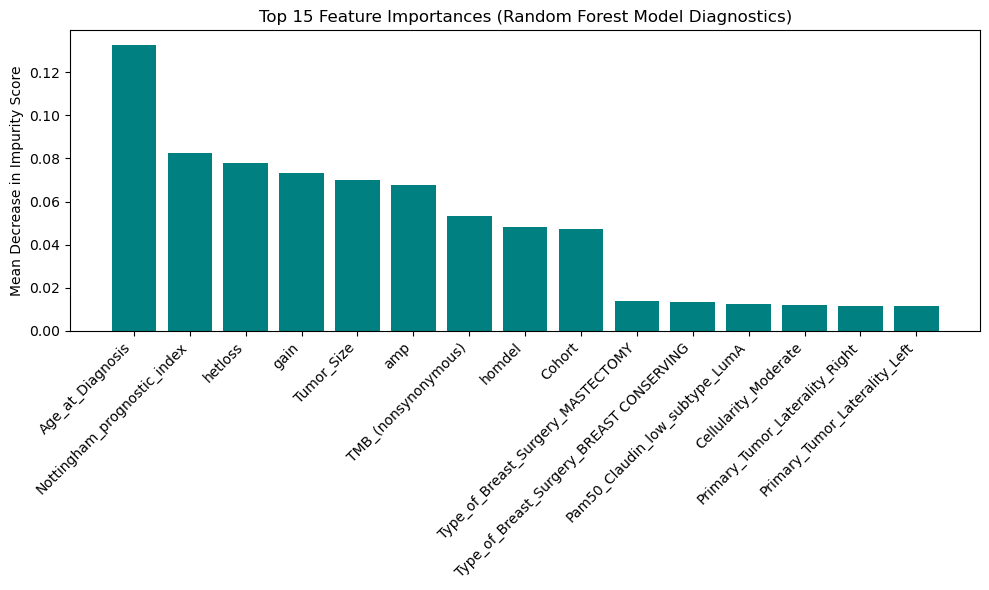

In [ ]:
# Visualizing the performance
plt.figure(figsize=(10, 6))
plt.bar(importances['Feature'].head(15), importances['Importance'].head(15), color="teal")
plt.title("Top 15 Feature Importances (Random Forest Model Diagnostics)")
plt.ylabel("Mean Decrease in Impurity Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator

kl = KneeLocator(range(1, len(importances.Importance) + 1), importances.Importance,
                 curve='convex', direction='decreasing')
print(f"Elbow at: {kl.elbow}")

Elbow at: 10


In [ ]:
# Extract final clean dataset for Machine Learning
selected_features = importances.Feature.tolist()[:11]
ML_READY_TRAIN = X[selected_features]
ML_READY_TRAIN['label'] = list(y)

# Save
ML_READY_TRAIN.to_csv("METABRIC_ML_READY_TRAIN.csv", index=False)


print(f"Final Consolidated Train Set Shape: {ML_READY_TRAIN.shape}")


NameError: name 'y' is not defined

/var/folders/nw/2dm_8qhd5rj3vc08k7bw9ss80000gn/T/ipykernel_61773/668820293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


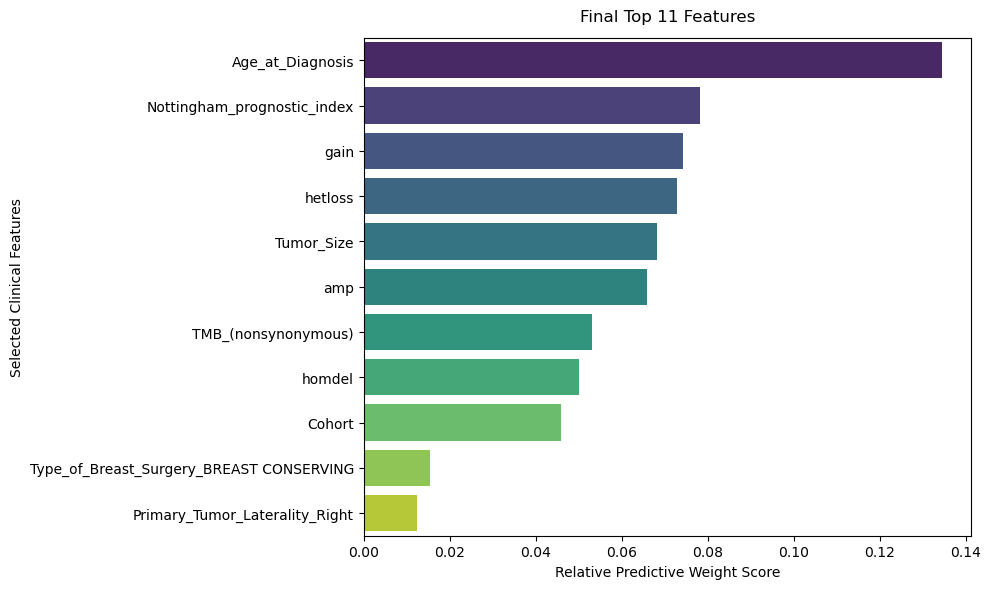

In [ ]:
##################################

# Isolate the top 11 features from your existing importance tracker dataframe
top_features = importances.head(11)

plt.rcParams['figure.figsize'] = (10, 6)
sns.barplot(
    data=top_features, 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title("Final Top 11 Features", fontsize=12, pad=12)
plt.xlabel("Relative Predictive Weight Score")
plt.ylabel("Selected Clinical Features")
plt.tight_layout()
plt.show()